# $$EuroSAT$$

## Project Overview
This project focuses on supervised image classification using the EuroSAT dataset.  
The goal is to classify satellite images into different land use categories by implementing a custom Convolutional Neural Network **(CNN)** in PyTorch.

## Objectives
- Load and explore the EuroSAT dataset
- Preprocess the images
- Build a custom CNN from scratch
- Train and evaluate the model
- Analyze the results

## Importing Libraries

In this step, I import the libraries required for data handling, visualization, and model implementation using TensorFlow.

In [1]:
import os
import random
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

from sklearn.metrics import confusion_matrix
import seaborn as sns

%matplotlib inline

import logging
logging.getLogger("tensorflow").setLevel(logging.ERROR)
tf.autograph.set_verbosity(0)

In [2]:
# Set random seed
seed = 42
tf.random.set_seed(seed)
np.random.seed(seed)
random.seed(seed)

## Loading the Dataset

In this step, I load the EuroSAT dataset from the folder and prepare it for training.

In [3]:
dataset_path = "EuroSAT"

train_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.3,
    subset="training",
    seed=42,
    image_size=(64, 64),
    batch_size=32
)

val_test_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.3,
    subset="validation",
    seed=42,
    image_size=(64, 64),
    batch_size=32
)

Found 27000 files belonging to 10 classes.
Using 18900 files for training.
Found 27000 files belonging to 10 classes.
Using 8100 files for validation.


## Splitting Validation and Test Sets

In this step, I split the remaining 30% of the data into validation and test sets.

In [4]:
val_batches = int(0.5 * len(val_test_ds))  

val_ds = val_test_ds.take(val_batches)   
test_ds = val_test_ds.skip(val_batches)

## Exploratory Data Analysis (EDA)

In this section, I inspect the dataset structure, class names, number of classes, and sample images.

### Checking Class Names

In this step, I inspect the class names in the dataset.

In [5]:
class_names = train_ds.class_names
print(class_names)
print("Number of classes:", len(class_names))

['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']
Number of classes: 10


### Class Distribution

In this step, I check how many images are available for each class.

In [6]:
for class_name in class_names:
    class_path = os.path.join(dataset_path, class_name)
    print(class_name, ":", len(os.listdir(class_path)))

AnnualCrop : 3000
Forest : 3000
HerbaceousVegetation : 3000
Highway : 2500
Industrial : 2500
Pasture : 2000
PermanentCrop : 2500
Residential : 3000
River : 2500
SeaLake : 3000


## Visualizing Sample Images

In this step, I display some sample images from the training set.

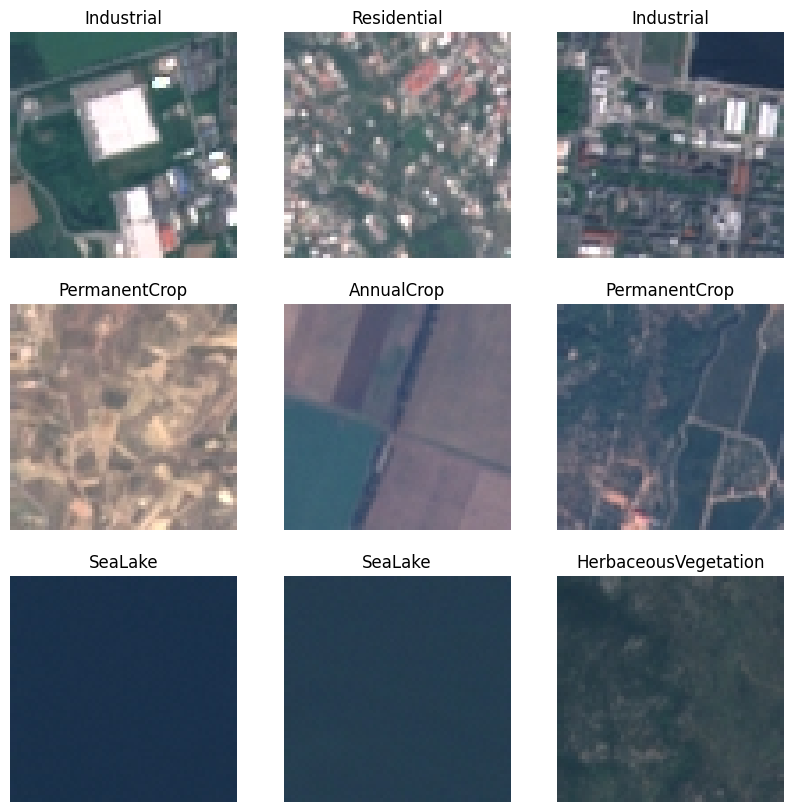

In [7]:
plt.figure(figsize=(10, 10))

for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

## Normalizing the Images

In this step, I normalize the pixel values so that they are in the range [0, 1].

In [7]:
normalization_layer = tf.keras.layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))
test_ds = test_ds.map(lambda x, y: (normalization_layer(x), y))

## Data Augmentation

In this step, I apply data augmentation to increase dataset diversity.

In [8]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
])

## Logistic Regression Baseline

In this step, I use a simple Logistic Regression model as a baseline for comparison.

In [10]:
X_train = []
y_train = []

for images, labels in train_ds:
    X_train.append(images.numpy())
    y_train.append(labels.numpy())

X_train = np.concatenate(X_train)
y_train = np.concatenate(y_train)

# flatten
X_train = X_train.reshape(X_train.shape[0], -1)

# test data

In [11]:
X_test = []
y_test = []

for images, labels in test_ds:
    X_test.append(images.numpy())
    y_test.append(labels.numpy())

X_test = np.concatenate(X_test)
y_test = np.concatenate(y_test)

X_test = X_test.reshape(X_test.shape[0], -1)

# Logistic Regression

In [12]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)

C:\Users\Lenovo\anaconda3\envs\llm\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

# Evaluation

In [13]:
lr_acc = lr_model.score(X_test, y_test)
print("Logistic Regression Accuracy:", lr_acc)

Logistic Regression Accuracy: 0.3946977205153617


## Building the CNN Model

In [17]:
model = tf.keras.Sequential([

    tf.keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(64, 64, 3)),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(64, activation='relu'),

    tf.keras.layers.Dense(10, activation='softmax')
])

## Compiling the Model

In this step, I define how the model will learn.

In [18]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

## Training the Model

In this step, I train the CNN on the training set and monitor its performance on the validation set.

In [20]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
591/591 [==============================] - 28s 47ms/step - loss: 1.3704 - accuracy: 0.4679 - val_loss: 1.0342 - val_accuracy: 0.6302
Epoch 2/10
591/591 [==============================] - 27s 46ms/step - loss: 0.9080 - accuracy: 0.6683 - val_loss: 0.8081 - val_accuracy: 0.7124
Epoch 3/10
591/591 [==============================] - 26s 43ms/step - loss: 0.7057 - accuracy: 0.7464 - val_loss: 0.6719 - val_accuracy: 0.7682
Epoch 4/10
591/591 [==============================] - 27s 46ms/step - loss: 0.6066 - accuracy: 0.7832 - val_loss: 0.6651 - val_accuracy: 0.7675
Epoch 5/10
591/591 [==============================] - 28s 48ms/step - loss: 0.5365 - accuracy: 0.8102 - val_loss: 0.5915 - val_accuracy: 0.7810
Epoch 6/10
591/591 [==============================] - 27s 46ms/step - loss: 0.4791 - accuracy: 0.8308 - val_loss: 0.8333 - val_accuracy: 0.7060
Epoch 7/10
591/591 [==============================] - 28s 47ms/step - loss: 0.4277 - accuracy: 0.8492 - val_loss: 0.6156 - val_accuracy:

##  Model Result


In [21]:
baseline_test_loss, baseline_test_acc = model.evaluate(test_ds)
print("Baseline Test Accuracy:", baseline_test_acc)
print("Baseline Test Loss:", baseline_test_loss)

127/127 [==============================] - 2s 14ms/step - loss: 0.5574 - accuracy: 0.8199
Baseline Test Accuracy: 0.819871187210083
Baseline Test Loss: 0.5574291348457336


## Learning Curves

In this step, I plot the training and validation accuracy and loss over epochs.

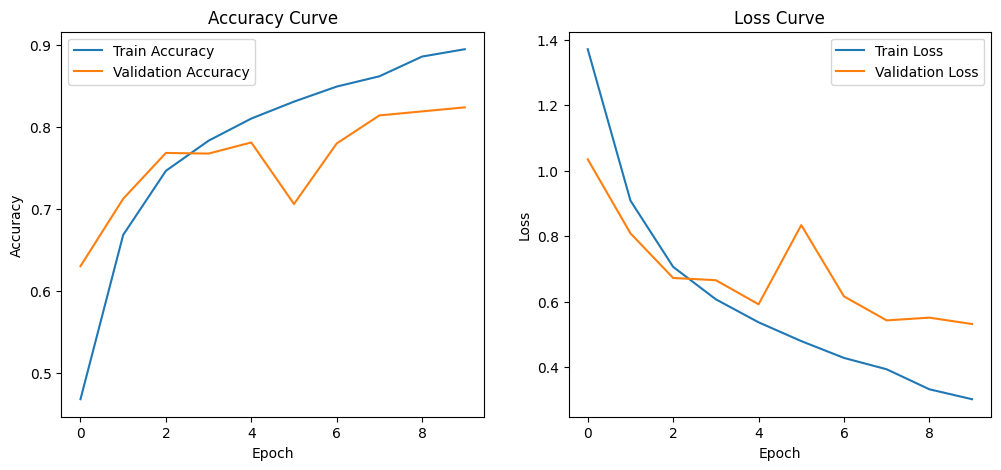

In [22]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy Curve')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss Curve')
plt.legend()

plt.show()

<BR/>

## Improved CNN: Extra Convolutional Layer

In this experiment, I add one extra convolutional layer to improve the model.

In [24]:
model_deep = tf.keras.Sequential([

    tf.keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(64,64,3)),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(128, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

# Compile

In [25]:
model_deep.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train

In [27]:
history_deep = model_deep.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
591/591 [==============================] - 29s 47ms/step - loss: 1.2357 - accuracy: 0.5272 - val_loss: 0.8261 - val_accuracy: 0.7131
Epoch 2/10
591/591 [==============================] - 27s 45ms/step - loss: 0.7899 - accuracy: 0.7114 - val_loss: 0.6876 - val_accuracy: 0.7697
Epoch 3/10
591/591 [==============================] - 26s 44ms/step - loss: 0.6440 - accuracy: 0.7679 - val_loss: 0.8390 - val_accuracy: 0.7072
Epoch 4/10
591/591 [==============================] - 26s 44ms/step - loss: 0.5662 - accuracy: 0.7960 - val_loss: 0.5120 - val_accuracy: 0.8216
Epoch 5/10
591/591 [==============================] - 28s 48ms/step - loss: 0.4918 - accuracy: 0.8206 - val_loss: 0.4990 - val_accuracy: 0.8152
Epoch 6/10
591/591 [==============================] - 28s 48ms/step - loss: 0.4379 - accuracy: 0.8419 - val_loss: 0.3967 - val_accuracy: 0.8565
Epoch 7/10
591/591 [==============================] - 27s 46ms/step - loss: 0.3888 - accuracy: 0.8611 - val_loss: 0.4467 - val_accuracy:

# Evaluate

In [29]:
aug_deep_loss, aug_deep_acc = model_deep.evaluate(test_ds)
print("Augmented Deep CNN Test Accuracy:", aug_deep_acc)
print("Augmented Deep CNN Test Loss:", aug_deep_loss)

127/127 [==============================] - 3s 15ms/step - loss: 0.4191 - accuracy: 0.8687
Augmented Deep CNN Test Accuracy: 0.8686818480491638
Augmented Deep CNN Test Loss: 0.41914284229278564


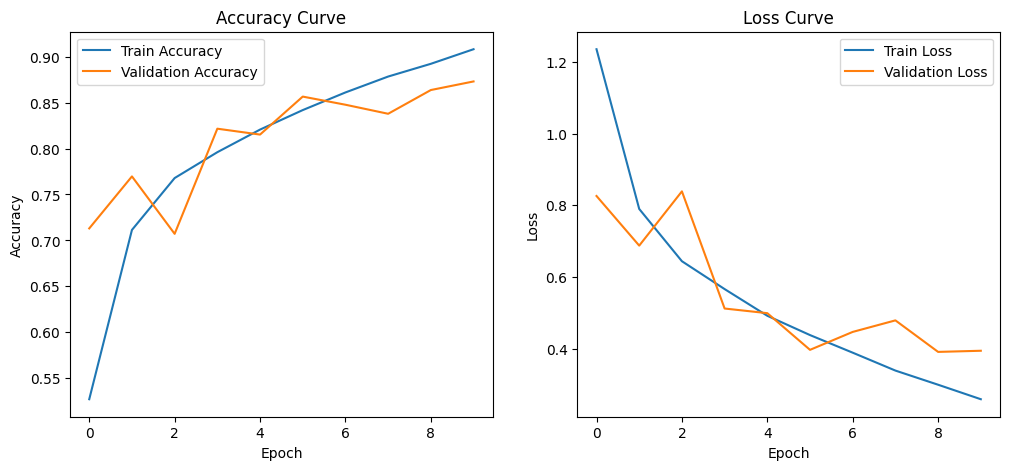

In [30]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history_deep.history['accuracy'], label='Train Accuracy')
plt.plot(history_deep.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy Curve')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history_deep.history['loss'], label='Train Loss')
plt.plot(history_deep.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss Curve')
plt.legend()

plt.show()

## Improved CNN: Extra Convolutional Layer (20 Epochs)

In [58]:
model_deep_20E = tf.keras.Sequential([

    tf.keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(64,64,3)),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(128, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

# Compile

In [59]:
model_deep_20E.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train

In [61]:
history_deep_20E = model_deep_20E.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20
)

Epoch 1/20
591/591 [==============================] - 28s 46ms/step - loss: 1.2571 - accuracy: 0.5092 - val_loss: 0.9082 - val_accuracy: 0.6671
Epoch 2/20
591/591 [==============================] - 26s 45ms/step - loss: 0.8137 - accuracy: 0.7071 - val_loss: 0.7830 - val_accuracy: 0.7092
Epoch 3/20
591/591 [==============================] - 27s 46ms/step - loss: 0.6682 - accuracy: 0.7562 - val_loss: 0.6215 - val_accuracy: 0.7677
Epoch 4/20
591/591 [==============================] - 28s 47ms/step - loss: 0.5847 - accuracy: 0.7891 - val_loss: 0.5520 - val_accuracy: 0.8000
Epoch 5/20
591/591 [==============================] - 28s 47ms/step - loss: 0.5249 - accuracy: 0.8114 - val_loss: 0.5154 - val_accuracy: 0.8162
Epoch 6/20
591/591 [==============================] - 28s 47ms/step - loss: 0.4682 - accuracy: 0.8296 - val_loss: 0.4147 - val_accuracy: 0.8497
Epoch 7/20
591/591 [==============================] - 28s 47ms/step - loss: 0.4205 - accuracy: 0.8502 - val_loss: 0.4574 - val_accuracy:

# Evaluate

In [67]:
aug_deep_loss, aug_deep_acc = model_deep_20E.evaluate(test_ds)
print("Augmented Deep CNN Test Accuracy:", aug_deep_acc)
print("Augmented Deep CNN Test Loss:", aug_deep_loss)

127/127 [==============================] - 3s 15ms/step - loss: 0.6803 - accuracy: 0.8605
Augmented Deep CNN Test Accuracy: 0.8605054616928101
Augmented Deep CNN Test Loss: 0.6803110241889954


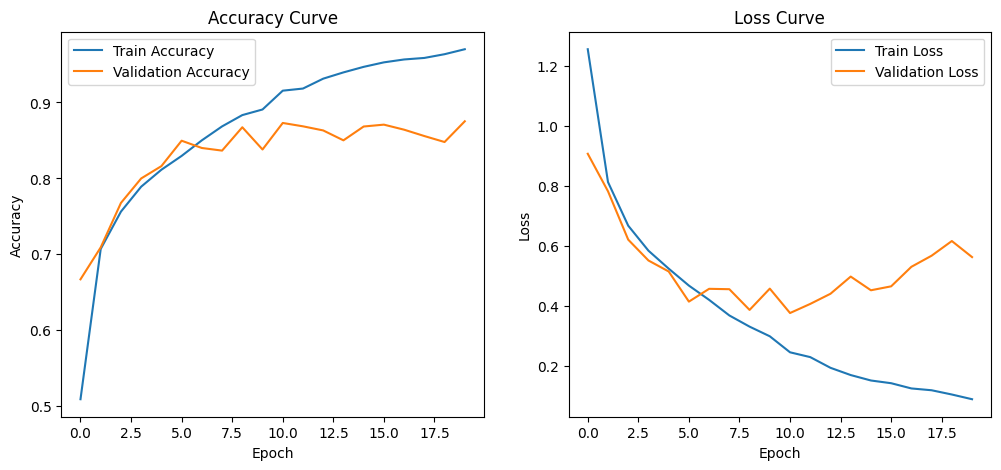

In [68]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history_deep_20E.history['accuracy'], label='Train Accuracy')
plt.plot(history_deep_20E.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy Curve')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history_deep_20E.history['loss'], label='Train Loss')
plt.plot(history_deep_20E.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss Curve')
plt.legend()

plt.show()

# Improved CNN: Data Augmentation

In [37]:
model_deep_aug = tf.keras.Sequential([
    
    data_augmentation,

    tf.keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(64,64,3)),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(128, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Flatten(),
    
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

# Compile

In [38]:
model_deep_aug.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train

In [39]:
history_deep_aug = model_deep_aug.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
591/591 [==============================] - 30s 49ms/step - loss: 1.3176 - accuracy: 0.5083 - val_loss: 1.0121 - val_accuracy: 0.6312
Epoch 2/10
591/591 [==============================] - 29s 49ms/step - loss: 0.8813 - accuracy: 0.6819 - val_loss: 0.7607 - val_accuracy: 0.7352
Epoch 3/10
591/591 [==============================] - 29s 50ms/step - loss: 0.7339 - accuracy: 0.7332 - val_loss: 0.7769 - val_accuracy: 0.7362
Epoch 4/10
591/591 [==============================] - 29s 49ms/step - loss: 0.6687 - accuracy: 0.7606 - val_loss: 0.6395 - val_accuracy: 0.7670
Epoch 5/10
591/591 [==============================] - 29s 49ms/step - loss: 0.6104 - accuracy: 0.7788 - val_loss: 0.5633 - val_accuracy: 0.7953
Epoch 6/10
591/591 [==============================] - 29s 48ms/step - loss: 0.5609 - accuracy: 0.7980 - val_loss: 0.6522 - val_accuracy: 0.7790
Epoch 7/10
591/591 [==============================] - 29s 50ms/step - loss: 0.5300 - accuracy: 0.8089 - val_loss: 0.5941 - val_accuracy:

# Evaluate

In [41]:
aug_deep_loss, aug_deep_acc = model_deep_aug.evaluate(test_ds)
print("Augmented Deep CNN Test Accuracy:", aug_deep_acc)
print("Augmented Deep CNN Test Loss:", aug_deep_loss)

127/127 [==============================] - 3s 16ms/step - loss: 0.5266 - accuracy: 0.8159
Augmented Deep CNN Test Accuracy: 0.815906822681427
Augmented Deep CNN Test Loss: 0.5265626907348633


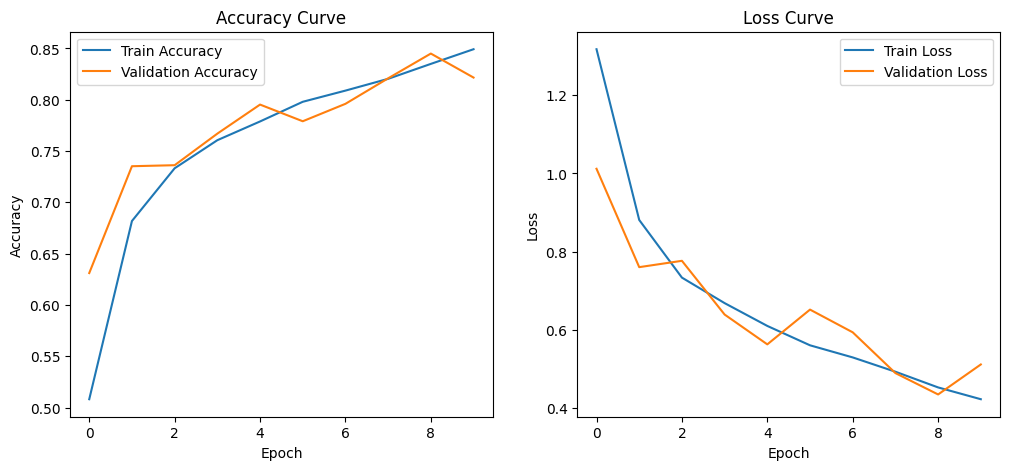

In [42]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history_deep_aug.history['accuracy'], label='Train Accuracy')
plt.plot(history_deep_aug.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy Curve')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history_deep_aug.history['loss'], label='Train Loss')
plt.plot(history_deep_aug.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss Curve')
plt.legend()

plt.show()

<br/>

## CNN with Dropout

In this step, I add dropout to reduce overfitting.

In [62]:
model_dropout = tf.keras.Sequential([

    tf.keras.layers.Conv2D(32, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(128, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.2),

    tf.keras.layers.Dense(10, activation='softmax')
])

In [63]:
model_dropout.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [64]:
history_dropout = model_dropout.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
591/591 [==============================] - 29s 48ms/step - loss: 1.3559 - accuracy: 0.4770 - val_loss: 0.8595 - val_accuracy: 0.6961
Epoch 2/10
591/591 [==============================] - 26s 44ms/step - loss: 0.9207 - accuracy: 0.6681 - val_loss: 0.7644 - val_accuracy: 0.7269
Epoch 3/10
591/591 [==============================] - 29s 49ms/step - loss: 0.7790 - accuracy: 0.7211 - val_loss: 0.8147 - val_accuracy: 0.7173
Epoch 4/10
591/591 [==============================] - 28s 47ms/step - loss: 0.6798 - accuracy: 0.7584 - val_loss: 0.5664 - val_accuracy: 0.8029
Epoch 5/10
591/591 [==============================] - 28s 46ms/step - loss: 0.6336 - accuracy: 0.7746 - val_loss: 0.6024 - val_accuracy: 0.7867
Epoch 6/10
591/591 [==============================] - 27s 46ms/step - loss: 0.5726 - accuracy: 0.7959 - val_loss: 0.5640 - val_accuracy: 0.7972
Epoch 7/10
591/591 [==============================] - 27s 46ms/step - loss: 0.5073 - accuracy: 0.8213 - val_loss: 0.4881 - val_accuracy:

In [65]:
dropout_test_loss, dropout_test_acc = model_dropout.evaluate(test_ds)
print("Dropout Test Accuracy:", dropout_test_acc)
print("Dropout Test Loss:", dropout_test_loss)

127/127 [==============================] - 3s 16ms/step - loss: 0.4704 - accuracy: 0.8412
Dropout Test Accuracy: 0.841179370880127
Dropout Test Loss: 0.4704452455043793


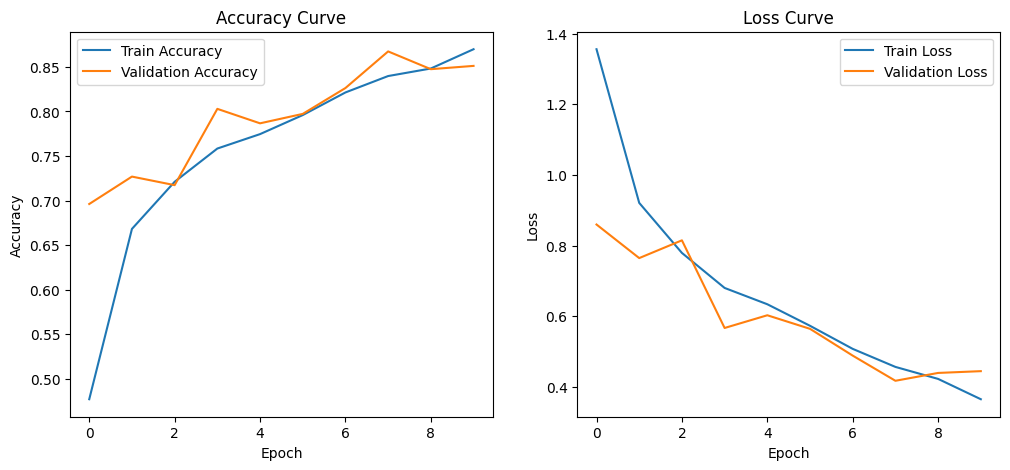

In [66]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history_dropout.history['accuracy'], label='Train Accuracy')
plt.plot(history_dropout.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy Curve')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history_dropout.history['loss'], label='Train Loss')
plt.plot(history_dropout.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss Curve')
plt.legend()

plt.show()

### Experiment: Increasing Training Epochs (Dropout = 0.2)

In this experiment, I increased the number of training epochs from 10 to 20 while keeping the same model architecture and dropout rate (0.2).

The goal is to check whether the model benefits from longer training or starts to overfit.

This helps evaluate if the model was undertrained in the previous setup.

In [50]:
model_dropout_20 = tf.keras.Sequential([

    data_augmentation,

    tf.keras.layers.Conv2D(32, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(128, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.2),

    tf.keras.layers.Dense(10, activation='softmax')
])

In [51]:
model_dropout_20.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [49]:
history_dropout_20 = model_dropout_20.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20
)

Epoch 1/20
591/591 [==============================] - 29s 48ms/step - loss: 1.3977 - accuracy: 0.4723 - val_loss: 1.0703 - val_accuracy: 0.5933
Epoch 2/20
591/591 [==============================] - 29s 49ms/step - loss: 0.9311 - accuracy: 0.6663 - val_loss: 0.9370 - val_accuracy: 0.6609
Epoch 3/20
591/591 [==============================] - 29s 49ms/step - loss: 0.7994 - accuracy: 0.7099 - val_loss: 0.8375 - val_accuracy: 0.6988
Epoch 4/20
591/591 [==============================] - 28s 47ms/step - loss: 0.7149 - accuracy: 0.7412 - val_loss: 0.8216 - val_accuracy: 0.7092
Epoch 5/20
591/591 [==============================] - 28s 47ms/step - loss: 0.6487 - accuracy: 0.7668 - val_loss: 0.6842 - val_accuracy: 0.7406
Epoch 6/20
591/591 [==============================] - 29s 49ms/step - loss: 0.6075 - accuracy: 0.7807 - val_loss: 0.6276 - val_accuracy: 0.7751
Epoch 7/20
591/591 [==============================] - 28s 48ms/step - loss: 0.5662 - accuracy: 0.7972 - val_loss: 0.6735 - val_accuracy:

In [52]:
dropout20_test_loss, dropout20_test_acc = model_dropout_20.evaluate(test_ds)
print("Dropout 0.2 (20 epochs) Test Accuracy:", dropout20_test_acc)
print("Dropout 0.2 (20 epochs) Test Loss:", dropout20_test_loss)

127/127 [==============================] - 3s 15ms/step - loss: 0.3114 - accuracy: 0.8997
Dropout 0.2 (20 epochs) Test Accuracy: 0.8996531367301941
Dropout 0.2 (20 epochs) Test Loss: 0.31140121817588806


## Early Stopping

In this step, I use early stopping to stop training when the validation performance no longer improves.

In [69]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

### Experiment: Dropout 0.2 + Early Stopping

In this experiment, I train the same model with dropout = 0.2 and use early stopping to automatically stop training at the best point.

In [70]:
model_es = tf.keras.Sequential([

    data_augmentation,

    tf.keras.layers.Conv2D(32, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(128, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.2),

    tf.keras.layers.Dense(10, activation='softmax')
])

model_es.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_es = model_es.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=[early_stop]
)

Epoch 1/30
591/591 [==============================] - 30s 48ms/step - loss: 1.4260 - accuracy: 0.4616 - val_loss: 0.9956 - val_accuracy: 0.6380
Epoch 2/30
591/591 [==============================] - 30s 50ms/step - loss: 0.9176 - accuracy: 0.6730 - val_loss: 0.8399 - val_accuracy: 0.7111
Epoch 3/30
591/591 [==============================] - 30s 51ms/step - loss: 0.8102 - accuracy: 0.7066 - val_loss: 0.7760 - val_accuracy: 0.7188
Epoch 4/30
591/591 [==============================] - 30s 51ms/step - loss: 0.7300 - accuracy: 0.7372 - val_loss: 0.7696 - val_accuracy: 0.7303
Epoch 5/30
591/591 [==============================] - 29s 49ms/step - loss: 0.6751 - accuracy: 0.7538 - val_loss: 0.6315 - val_accuracy: 0.7667
Epoch 6/30
591/591 [==============================] - 29s 50ms/step - loss: 0.6214 - accuracy: 0.7751 - val_loss: 0.7516 - val_accuracy: 0.7367
Epoch 7/30
591/591 [==============================] - 30s 51ms/step - loss: 0.5822 - accuracy: 0.7908 - val_loss: 0.5704 - val_accuracy:

In [71]:
es_test_loss, es_test_acc = model_es.evaluate(test_ds)
print("EarlyStopping Test Accuracy:", es_test_acc)
print("EarlyStopping Test Loss:", es_test_loss)

127/127 [==============================] - 3s 16ms/step - loss: 0.2732 - accuracy: 0.9051
EarlyStopping Test Accuracy: 0.9051040410995483
EarlyStopping Test Loss: 0.2731873691082001


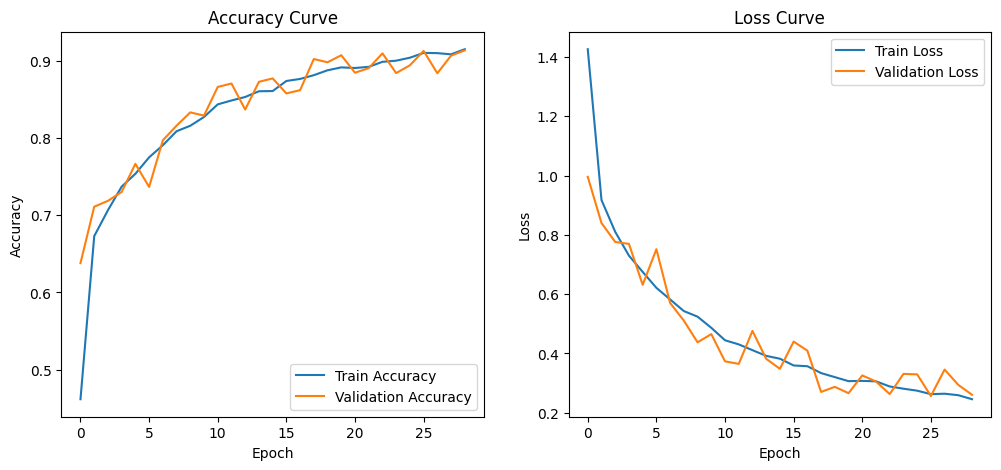

In [72]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history_es.history['accuracy'], label='Train Accuracy')
plt.plot(history_es.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy Curve')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history_es.history['loss'], label='Train Loss')
plt.plot(history_es.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss Curve')
plt.legend()

plt.show()

## Confusion Matrix

In this step, I compute the confusion matrix to analyze the model’s predictions across classes.

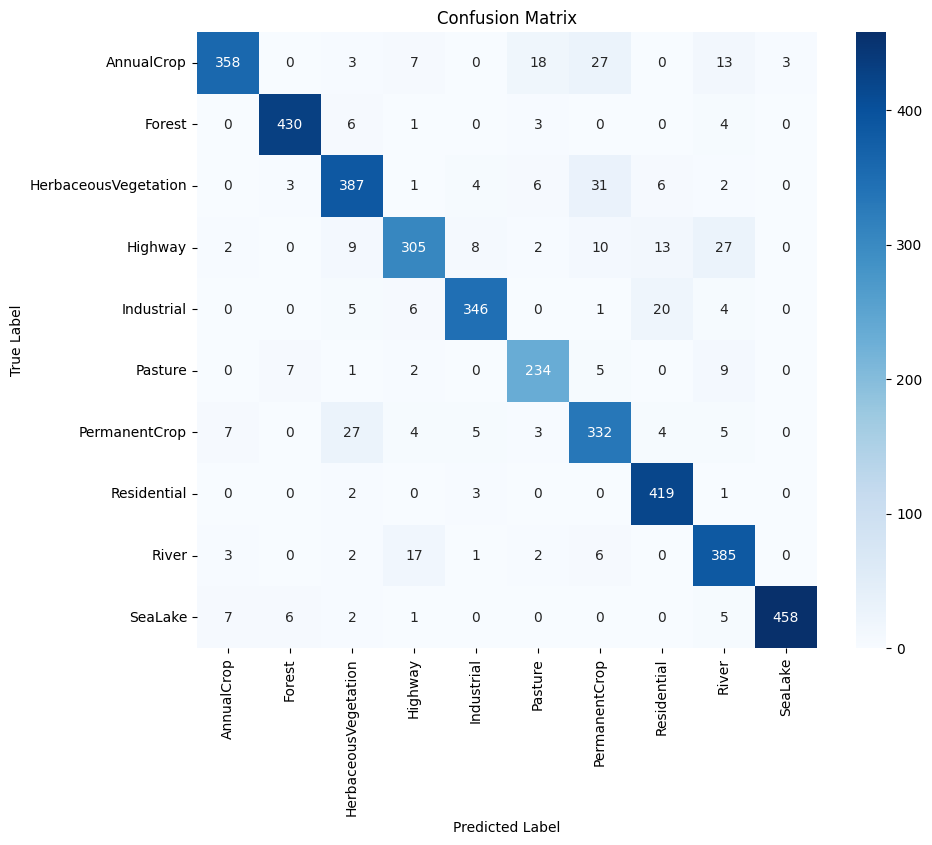

In [73]:
y_true = []
y_pred = []

for images, labels in test_ds:
    predictions = model_es.predict(images, verbose=0)
    predicted_labels = np.argmax(predictions, axis=1)
    
    y_true.extend(labels.numpy())
    y_pred.extend(predicted_labels)

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

## Misclassified Images

In this step, I display some test images that were classified incorrectly.

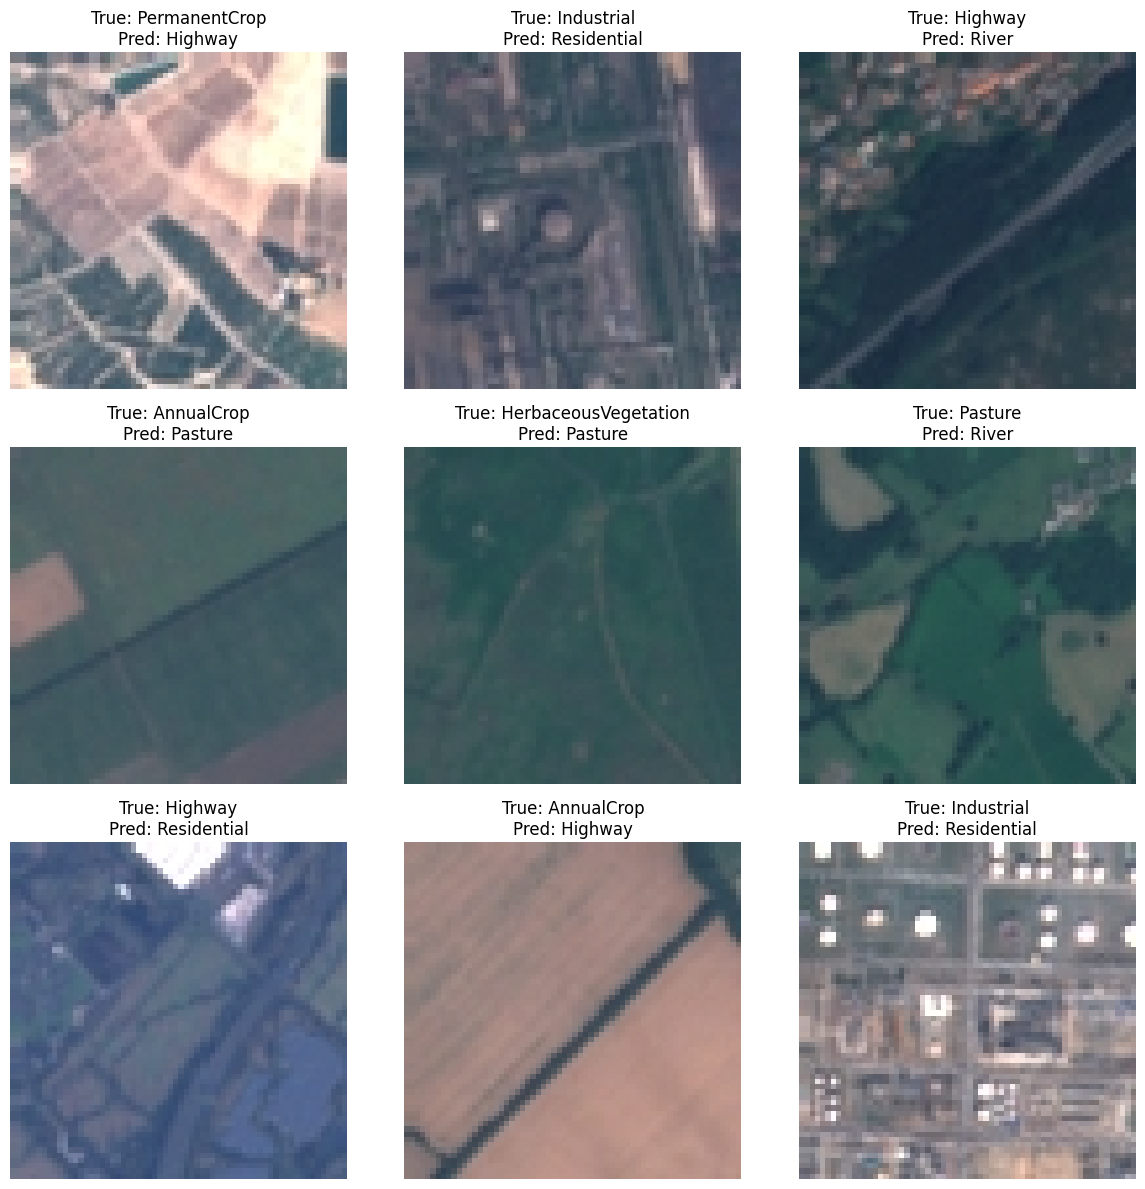

In [74]:
misclassified_images = []
misclassified_true = []
misclassified_pred = []

for images, labels in test_ds:
    predictions = model_es.predict(images, verbose=0)
    predicted_labels = np.argmax(predictions, axis=1)

    for i in range(len(labels)):
        if predicted_labels[i] != labels[i]:
            misclassified_images.append(images[i].numpy())
            misclassified_true.append(class_names[labels[i]])
            misclassified_pred.append(class_names[predicted_labels[i]])

plt.figure(figsize=(12, 12))

for i in range(min(9, len(misclassified_images))):
    plt.subplot(3, 3, i + 1)
    plt.imshow(misclassified_images[i])
    plt.title(f"True: {misclassified_true[i]}\nPred: {misclassified_pred[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

## Final Model Comparison

| Model | Main Change | Train Acc | Val Acc | Test Acc | Test Loss | Comment |
|---|---|---|---|---|---|---|
| Logistic Regression | Flattened image baseline | - | - | 0.3947 | - | Weak baseline |
| Baseline CNN | 2 Conv layers, 10 epochs | ~0.89 | ~0.82 | 0.8199 | 0.5574 | Good baseline |
| Improved CNN | 3 Conv layers, 10 epochs | ~0.91 | ~0.87 | 0.8687 | 0.4191 | Better features |
| CNN (3 layers, 20 epochs) | More training | ~0.97 | ~0.87 | 0.8605 | 0.6803 | Overfitting |
| CNN + Dropout 0.2 | Regularization | ~0.87 | ~0.85 | 0.8412 | 0.4704 | More stable |
| CNN + Data Augmentation | Data diversity | ~0.84 | ~0.82 | 0.8159 | 0.5266 | No gain |
| CNN + Aug + Dropout 0.2 | Combined | ~0.90 | ~0.90 | 0.8997 | 0.3114 | Strong model |
| Final Model | + Early Stopping | ~0.91 | ~0.91 | 0.9051 | 0.2732 | Best model |

## Conclusion

In this project, different CNN architectures and techniques were tested for image classification on the EuroSAT dataset.

The results show that simply increasing model complexity does not always improve performance. In some cases, deeper models or longer training led to overfitting.

Regularization techniques such as dropout and data augmentation helped improve generalization when used together.

The best performance was achieved by combining data augmentation, dropout (0.2), and early stopping, reaching a test accuracy of about 90.5%.

This shows the importance of balancing model complexity and regularization to achieve strong and stable results.